# MLP Regressor para previsão de temperatura em Jena


## Base de dados

Base: `jena_climate_2009_2016.csv`

Série meteorológica de Jena, agregada de 10 minutos para frequência horária. O alvo é a temperatura do ar `T (degC)`.

- Granularidade: horária
- Random state: 42
- Divisão temporal: 80% inicial para treino e 20% final para teste


## Importações e configurações


In [1]:
from copy import deepcopy
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import sys

PROJECT_ROOT = next(
    (pasta for pasta in (Path.cwd(), *Path.cwd().parents)
     if (pasta / 'validacao_bases.py').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Não foi possível localizar validacao_bases.py a partir do diretório atual.'
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from funcoes_series_temporais import (
    analisar_componente_residual, calcular_forca_sazonalidade,
    calcular_importancia_features,
)

In [2]:
BASE_NAME = "clima"
SEED = 42
HORIZON = 1
SEASONAL_PERIOD = 24
print(f"Base: {BASE_NAME}")

Base: clima


## Configuração do MLP Regressor


In [3]:
# Configuração causal compartilhada para a base selecionada.
from features_temporais import configuracao_features

FEATURE_CONFIG = configuracao_features(BASE_NAME)
TARGET_LAGS = list(FEATURE_CONFIG.lags_alvo)
EXOG_LAGS = {coluna: list(lags) for coluna, lags in FEATURE_CONFIG.lags_exogenas.items()}
EXOG_COLUMNS = list(EXOG_LAGS)
ROLLING_WINDOWS = list(FEATURE_CONFIG.janelas_moveis)
CALENDAR_COMPONENTS = list(FEATURE_CONFIG.calendario)
KNOWN_INDICATORS = dict(FEATURE_CONFIG.indicadores_conhecidos)
SCALER = 'standard'
VALIDATION_RATIO = 0.15
PATIENCE = 20
MIN_DELTA = 1e-4
BATCH_SIZE = 128  # lote maior para manter a busca temporal executável
N_SPLITS_VALIDACAO = 3
MESES_VALIDACAO = 6
MAX_AMOSTRA_MAE_TREINO = 5000
CANDIDATOS_MLP = [
    {'nome': 'simples_32_relu_adam', 'hidden_layer_sizes': (32,), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-4, 'max_iter': 100},
    {'nome': 'media_64_relu_adam', 'hidden_layer_sizes': (64,), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-3, 'max_iter': 120},
    {'nome': 'aula_64x64_relu_adam', 'hidden_layer_sizes': (64, 64), 'activation': 'relu', 'solver': 'adam', 'alpha': 1e-4, 'max_iter': 100},
    {'nome': 'simples_32_tanh_adam', 'hidden_layer_sizes': (32,), 'activation': 'tanh', 'solver': 'adam', 'alpha': 1e-3, 'max_iter': 100},
    {'nome': 'simples_32_relu_sgd', 'hidden_layer_sizes': (32,), 'activation': 'relu', 'solver': 'sgd', 'alpha': 1e-4, 'max_iter': 120},
]

# 1. Preparação da base


## Base tratada

- **Objetivo:** carregar a série horária já limpa e preservar o corte cronológico entre treino e teste.
- **Importância:** todos os modelos partem da mesma amostra, permitindo uma comparação justa.
- **Cuidado:** os lags são calculados antes da remoção das linhas incompletas para manter o alinhamento temporal.


In [4]:
# Carrega a base tratada e verifica sua integridade.
from preparacao_bases import carregar_base_tratada

df, metadados_base = carregar_base_tratada(BASE_NAME, PROJECT_ROOT)
TARGET_COLUMN = metadados_base['alvo']
FREQUENCY = metadados_base['frequencia']
TRAIN_RATIO = metadados_base['treino']
SEED = metadados_base['seed']
FIM_TREINO = pd.Timestamp(metadados_base['fim_treino'])
INICIO_TESTE = pd.Timestamp(metadados_base['inicio_teste'])
np.random.seed(SEED)
diagnostico_base = pd.DataFrame([{
    'base': BASE_NAME, 'linhas': len(df), 'alvos_ausentes': int(df[TARGET_COLUMN].isna().sum()),
    'fim_treino': FIM_TREINO, 'inicio_teste': INICIO_TESTE, 'seed': SEED,
}])
display(diagnostico_base)

,base,linhas,alvos_ausentes,fim_treino,inicio_teste,seed
0,clima,70129,88,2015-05-27 14:00:00,2015-05-27 15:00:00,42


## Dicionário de dados

- **Alvo:** temperatura do ar `T (degC)`.
- **Exógenas:** pressão, umidade, vento e direção do vento.
- **Importância:** registrar quando cada variável está disponível evita utilizar informações futuras na previsão.


In [5]:
# Registra o papel e a disponibilidade temporal das variáveis.
dicionario = pd.DataFrame([
    {
        'variavel': coluna,
        'papel': 'alvo' if coluna == TARGET_COLUMN else 'exogena',
        'tipo': str(df[coluna].dtype),
        'uso_no_modelo': 'somente valores defasados; calendário é conhecido antecipadamente',
    }
    for coluna in [TARGET_COLUMN] + EXOG_COLUMNS
]).set_index('variavel')
display(dicionario)

,papel,tipo,uso_no_modelo
variavel,,,
T (degC),alvo,float64,somente valores defasados; calendário é conhec...
p (mbar),exogena,float64,somente valores defasados; calendário é conhec...
rh (%),exogena,float64,somente valores defasados; calendário é conhec...
wv (m/s),exogena,float64,somente valores defasados; calendário é conhec...
wd_sin,exogena,float64,somente valores defasados; calendário é conhec...
wd_cos,exogena,float64,somente valores defasados; calendário é conhec...


## Análise exploratória

A exploração verifica:

- distribuição e evolução temporal das variáveis;
- valores ausentes e possíveis outliers pelo intervalo interquartil;
- padrões que podem orientar lags e janelas móveis.

> Os outliers são sinalizados, mas não removidos automaticamente, pois temperaturas extremas podem ser observações válidas.


,n,ausentes,media,desvio_padrao,minimo,q1,mediana,q3,maximo,limite_iqr_inferior,limite_iqr_superior,sinais_outlier_iqr,percentual_outlier_iqr
variavel,,,,,,,,,,,,,
T (degC),70041,88,9.442,8.415,-22.653,3.358,9.410,15.462,37.038,-14.797,33.617,248,0.004
p (mbar),70053,76,989.214,8.358,934.905,984.207,989.570,994.725,1015.243,968.429,1010.503,1124,0.016
rh (%),70053,76,76.029,16.385,13.683,65.305,79.267,89.350,100.000,29.237,125.418,130,0.002
wv (m/s),70053,76,2.129,1.465,0.000,1.037,1.768,2.818,12.895,-1.636,5.491,2494,0.036
wd_sin,70053,76,-0.168,0.548,-0.999,-0.618,-0.206,0.291,0.999,-1.983,1.656,0,0.000
wd_cos,70053,76,-0.288,0.652,-1.000,-0.864,-0.498,0.218,1.000,-2.486,1.840,0,0.000


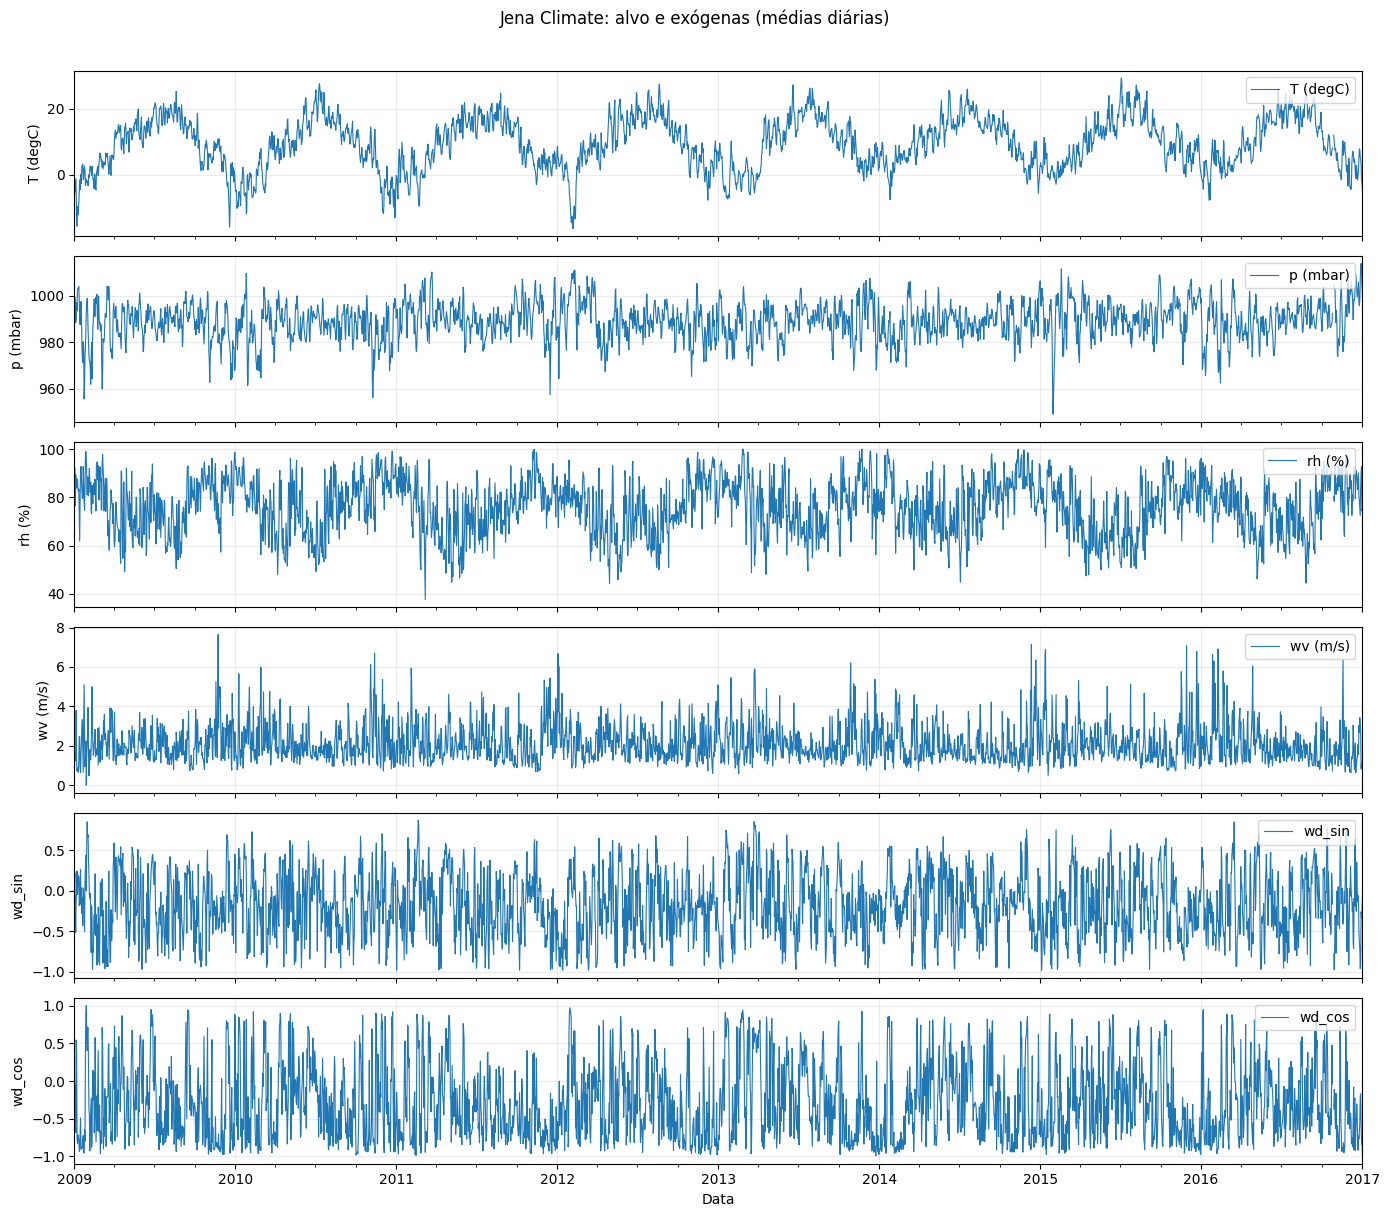

Decisão: preservar valores extremos fisicamente plausíveis; não aplicar clipping global.
Na modelagem, o alvo não é imputado; somente exógenas usam forward-fill causal de até 6 horas.


In [6]:
# Diagnóstico visual e sinais de outlier, sem remoção automática.
def diagnosticar_exploracao(dados, colunas, fator_iqr=1.5):
    faltantes = [coluna for coluna in colunas if coluna not in dados.columns]
    if faltantes:
        raise KeyError(f'Colunas ausentes na base: {faltantes}')
    linhas = []
    for coluna in colunas:
        serie = pd.to_numeric(dados[coluna], errors='coerce')
        validos = serie.dropna()
        q1, q3 = validos.quantile([0.25, 0.75])
        iqr = q3 - q1
        inferior, superior = q1 - fator_iqr * iqr, q3 + fator_iqr * iqr
        outliers = ((validos < inferior) | (validos > superior)).sum()
        linhas.append({
            'variavel': coluna, 'n': int(validos.size),
            'ausentes': int(serie.isna().sum()), 'media': float(validos.mean()),
            'desvio_padrao': float(validos.std()), 'minimo': float(validos.min()),
            'q1': float(q1), 'mediana': float(validos.median()), 'q3': float(q3),
            'maximo': float(validos.max()), 'limite_iqr_inferior': float(inferior),
            'limite_iqr_superior': float(superior), 'sinais_outlier_iqr': int(outliers),
            'percentual_outlier_iqr': float(outliers / max(1, validos.size)),
        })
    return pd.DataFrame(linhas).set_index('variavel')

colunas_t03 = [TARGET_COLUMN] + EXOG_COLUMNS
resumo_t03 = diagnosticar_exploracao(df, colunas_t03)
display(resumo_t03.round(3))

fig, axes = plt.subplots(len(colunas_t03), 1, figsize=(14, 12), sharex=True)
for ax, coluna in zip(axes, colunas_t03):
    df[coluna].resample('1D').mean().plot(ax=ax, linewidth=0.8, label=coluna)
    ax.set_ylabel(coluna)
    ax.legend(loc='upper right')
    ax.grid(alpha=0.25)
axes[-1].set_xlabel('Data')
fig.suptitle('Jena Climate: alvo e exógenas (médias diárias)', y=1.01)
plt.tight_layout()
plt.show()

print('Decisão: preservar valores extremos fisicamente plausíveis; não aplicar clipping global.')
print('Na modelagem, o alvo não é imputado; somente exógenas usam forward-fill causal de até 6 horas.')

# 2. Sazonalidade


## Decomposição STL

A STL separa a série de treino em três componentes:

- **tendência:** movimento de longo prazo;
- **sazonalidade:** padrão diário recorrente;
- **resíduo:** variação não explicada pelos dois componentes anteriores.

Essa separação ajuda a confirmar se os ciclos usados nas features realmente existem na série.


STL no treino: 2009-01-01 00:00:00 a 2014-09-24 17:00:00 (50,226 horas)


Força sazonal diária: 0.6929
Força de tendência: 0.9595


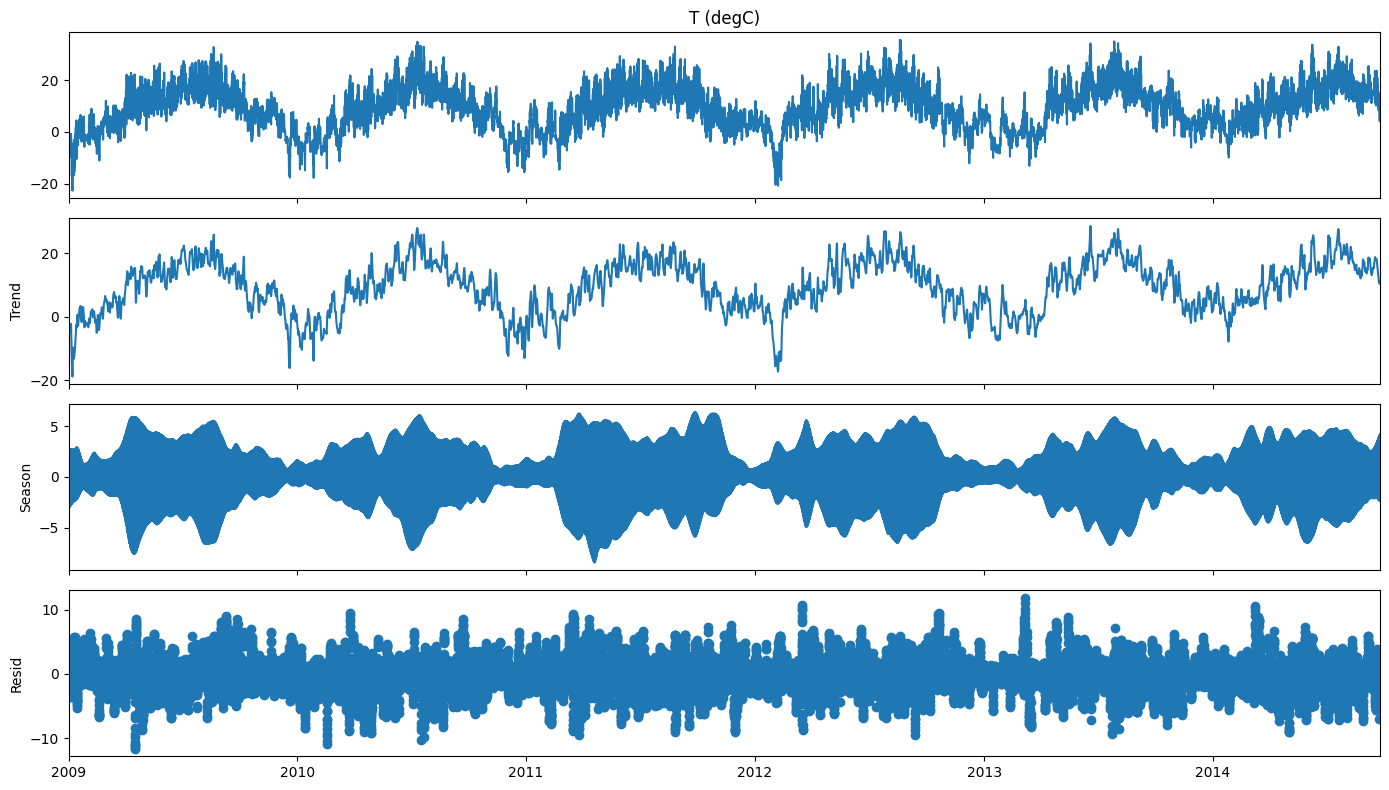

In [7]:
# Seleciona o maior trecho horário contínuo para a decomposição.
def maior_trecho_continuo(serie):
    observada = serie.dropna().sort_index()
    blocos = observada.index.to_series().diff().ne(pd.Timedelta(hours=1)).cumsum()
    grupos = list(observada.groupby(blocos.to_numpy()))
    return max(grupos, key=lambda par: len(par[1]))[1].asfreq('h')

serie_stl = maior_trecho_continuo(df.loc[df.index < INICIO_TESTE, TARGET_COLUMN])
assert serie_stl.notna().all()
print(f'STL no treino: {serie_stl.index.min()} a {serie_stl.index.max()} ({len(serie_stl):,} horas)')
stl_resultado = calcular_forca_sazonalidade(serie_stl, periodo=SEASONAL_PERIOD)
decomposicao = stl_resultado['decomposicao']
print(f"Força sazonal diária: {stl_resultado['forca_sazonalidade']:.4f}")
print(f"Força de tendência: {stl_resultado['forca_tendencia']:.4f}")
fig = decomposicao.plot(); fig.set_size_inches(14, 8)
plt.tight_layout(); plt.show()

## Força da sazonalidade e resíduos

- **Força sazonal:** quantifica quanto da variação é explicada pelo ciclo diário.
- **Força da tendência:** indica a relevância das mudanças de longo prazo.
- **Resíduos:** devem apresentar média próxima de zero e pouca estrutura temporal.

A autocorrelação residual sugere quais dependências ainda podem não ter sido capturadas.


In [8]:
# Analisa a sazonalidade e os resíduos da decomposição.
analise_residuos_stl = analisar_componente_residual(decomposicao, lags=24)
print(f"Média do residual: {analise_residuos_stl['media']:.6f}")
print(f"Desvio-padrão do residual: {analise_residuos_stl['desvio_padrao']:.6f}")
display(analise_residuos_stl["autocorrelacao_residual"])

Média do residual: -0.064830
Desvio-padrão do residual: 1.660688


,lb_stat,lb_pvalue
1,42872.998959,0.0
2,73753.473859,0.0
3,93368.126186,0.0
4,104030.418499,0.0
5,108637.517936,0.0
6,109905.840070,0.0
7,109967.094681,0.0
8,110183.229168,0.0
9,111203.311940,0.0
10,113106.206035,0.0


# 3. Features e validação


## Pipeline de features

As entradas do modelo combinam:

- **lags do alvo:** histórico recente da temperatura;
- **lags exógenos:** condições meteorológicas já observadas;
- **janelas móveis:** nível e variabilidade recentes;
- **calendário cíclico:** hora e época do ano sem quebras artificiais entre ciclos.

> Todas as features são causais: nenhuma medição posterior ao instante previsto é utilizada.


In [9]:
# Gera features causais na grade temporal completa.
from features_temporais import construir_features_temporais

model_data = construir_features_temporais(
    df, TARGET_COLUMN,
    lags_alvo=TARGET_LAGS,
    lags_exogenas=EXOG_LAGS,
    janelas_moveis=ROLLING_WINDOWS,
    calendario=CALENDAR_COMPONENTS,
    indicadores_conhecidos=KNOWN_INDICATORS,
    horizonte=HORIZON, frequencia=FREQUENCY, remover_incompletos=True,
)

train = model_data.loc[model_data.index < INICIO_TESTE]
test = model_data.loc[model_data.index >= INICIO_TESTE]
if train.empty or test.empty or train.index.max() >= test.index.min():
    raise ValueError("Divisão temporal inválida.")
y_train, y_test = train["target"], test["target"]
X_train, X_test = train.drop(columns="target"), test.drop(columns="target")

print(f"Features: {X_train.shape[1]} | treino: {len(train):,} | teste final: {len(test):,}")
print(f"Corte comum: {FIM_TREINO} -> {INICIO_TESTE}")

Features: 30 | treino: 55,752 | teste final: 13,785
Corte comum: 2015-05-27 14:00:00 -> 2015-05-27 15:00:00


## Escalonamento

O MLP é sensível a diferenças de escala entre as variáveis, para combater isso devemos escalonar.
- **StandardScaler:** centraliza cada feature e ajusta sua dispersão, favorecendo a otimização dos pesos.
- **Sem vazamento:** imputador e scaler aprendem somente com o trecho de treino e apenas transformam validação e teste.


In [10]:
# Ajusta o escalonamento apenas no trecho de treino.
def validar_X(X, nome):
    if not isinstance(X, pd.DataFrame) or X.empty:
        raise ValueError(f'{nome} deve ser um DataFrame não vazio')
    nao_numericas = X.select_dtypes(exclude='number').columns.tolist()
    if nao_numericas:
        raise TypeError(f'{nome} contém colunas não numéricas: {nao_numericas}')
    if np.isinf(X.to_numpy(dtype=float)).any():
        raise ValueError(f'{nome} contém valores infinitos')
    if isinstance(X.index, pd.DatetimeIndex) and not X.index.is_monotonic_increasing:
        raise ValueError(f'{nome} deve estar em ordem temporal crescente')

def criar_escalonador(tipo):
    if tipo == 'standard':
        return StandardScaler()
    if tipo == 'minmax':
        return MinMaxScaler()
    raise ValueError("tipo deve ser 'standard' ou 'minmax'")

n_validacao = max(24 * 30, int(len(X_train) * VALIDATION_RATIO))
X_ajuste, X_validacao = X_train.iloc[:-n_validacao], X_train.iloc[-n_validacao:]
y_ajuste, y_validacao = y_train.iloc[:-n_validacao], y_train.iloc[-n_validacao:]
preprocessador_validacao = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalonador', criar_escalonador(SCALER)),
])
X_ajuste_sc = preprocessador_validacao.fit_transform(X_ajuste)
X_validacao_sc = preprocessador_validacao.transform(X_validacao)
escalonador_validacao = preprocessador_validacao.named_steps['escalonador']
if int(escalonador_validacao.n_samples_seen_) != len(X_ajuste):
    raise AssertionError('O escalonador consultou dados fora da janela de ajuste.')
diagnostico_escala = pd.DataFrame({
    'media_ajuste_escalado': X_ajuste_sc.mean(axis=0),
    'media_validacao_escalada': X_validacao_sc.mean(axis=0),
}, index=X_train.columns)
display(diagnostico_escala.head(10).round(4))
print('Escala validada: fit no passado; validação recebeu somente transform().')

,media_ajuste_escalado,media_validacao_escalada
target_lag_1,-0.0,0.1214
target_lag_2,-0.0,0.1215
target_lag_3,0.0,0.1216
target_lag_6,-0.0,0.1218
target_lag_12,0.0,0.1229
target_lag_24,-0.0,0.1269
target_lag_48,-0.0,0.1323
target_lag_168,-0.0,0.1358
p (mbar)_lag_1,-0.0,0.1236
p (mbar)_lag_24,0.0,0.1229


Escala validada: fit no passado; validação recebeu somente transform().


## Validação temporal

- São usados **três folds cronológicos de seis meses**.
- Em cada fold, o treino sempre ocorre antes da validação.
- A configuração é escolhida pela média do MAE nos folds.
- No teste final, modelo e scaler permanecem congelados.

Esse protocolo simula o uso real e mantém o teste final independente da seleção do modelo.


In [11]:
# Cria três folds cronológicos de seis meses.
fim_desenvolvimento = INICIO_TESTE
folds, linhas_folds = [], []
for i in range(N_SPLITS_VALIDACAO):
    inicio_val = fim_desenvolvimento - pd.DateOffset(
        months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i)
    )
    fim_val = fim_desenvolvimento - pd.DateOffset(
        months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i - 1)
    )
    ia = np.flatnonzero(X_train.index < inicio_val)
    iv = np.flatnonzero((X_train.index >= inicio_val) & (X_train.index < fim_val))
    if not len(ia) or not len(iv):
        raise ValueError('Fold temporal vazio.')
    assert X_train.index[ia].max() < X_train.index[iv].min() < INICIO_TESTE
    folds.append((ia, iv))
    linhas_folds.append({
        'fold': i + 1, 'treino_ate': X_train.index[ia].max(),
        'validacao_inicio': X_train.index[iv].min(),
        'validacao_fim': X_train.index[iv].max(),
        'n_treino': len(ia), 'n_validacao': len(iv),
    })
fold_table = pd.DataFrame(linhas_folds)
display(fold_table)
np.testing.assert_allclose(
    model_data['target_lag_1'], df[TARGET_COLUMN].shift(1).reindex(model_data.index)
)
print(f'Origens finais: {len(X_test):,} | horizonte: {HORIZON} hora | modelo congelado no teste.')

,fold,treino_ate,validacao_inicio,validacao_fim,n_treino,n_validacao
0,1,2013-11-27 14:00:00,2013-11-27 15:00:00,2014-05-27 14:00:00,42831,4344
1,2,2014-05-27 14:00:00,2014-05-27 15:00:00,2014-11-27 14:00:00,47175,4233
2,3,2014-11-27 14:00:00,2014-11-27 15:00:00,2015-05-27 14:00:00,51408,4344


Origens finais: 13,785 | horizonte: 1 hora | modelo congelado no teste.


# 4. Modelagem MLP


## Arquitetura e otimização

Cinco configurações compactas são comparadas variando:

- quantidade de camadas e neurônios;
- função de ativação e otimizador;
- regularização `alpha` e limite de épocas.

**Critério de seleção:** menor MAE médio nos folds temporais. Os 15% finais de cada treino controlam o **early stopping**, interrompendo o ajuste quando a validação deixa de melhorar.


In [12]:
# Avalia as configurações com early stopping e validação temporal.
def treinar_com_early_stopping(configuracao, X_desenvolvimento, y_desenvolvimento):
    n_interno = max(24 * 30, int(len(X_desenvolvimento) * VALIDATION_RATIO))
    X_fit, X_val = X_desenvolvimento.iloc[:-n_interno], X_desenvolvimento.iloc[-n_interno:]
    y_fit, y_val = y_desenvolvimento.iloc[:-n_interno], y_desenvolvimento.iloc[-n_interno:]
    preprocessador = Pipeline([
        ('imputador', SimpleImputer(strategy='median')),
        ('escalonador', criar_escalonador(SCALER)),
    ])
    X_fit_sc = preprocessador.fit_transform(X_fit)
    X_val_sc = preprocessador.transform(X_val)
    modelo = MLPRegressor(
        hidden_layer_sizes=configuracao['hidden_layer_sizes'],
        activation=configuracao['activation'], solver=configuracao['solver'],
        alpha=configuracao['alpha'], batch_size=BATCH_SIZE, max_iter=1,
        warm_start=True, early_stopping=False, shuffle=True, random_state=SEED,
    )
    melhor_modelo, melhor_mae, melhor_epoca, sem_melhora = None, np.inf, 0, 0
    linhas = []
    inicio_amostra = max(0, len(X_fit_sc) - MAX_AMOSTRA_MAE_TREINO)
    for epoca in range(1, configuracao['max_iter'] + 1):
        modelo.partial_fit(X_fit_sc, y_fit)
        mae_treino = mean_absolute_error(
            y_fit.iloc[inicio_amostra:], modelo.predict(X_fit_sc[inicio_amostra:])
        )
        mae_validacao = mean_absolute_error(y_val, modelo.predict(X_val_sc))
        linhas.append({'epoca': epoca, 'MAE_treino': mae_treino, 'MAE_validacao': mae_validacao})
        if mae_validacao < melhor_mae - MIN_DELTA:
            melhor_modelo, melhor_mae, melhor_epoca = deepcopy(modelo), mae_validacao, epoca
            sem_melhora = 0
        else:
            sem_melhora += 1
            if sem_melhora >= PATIENCE:
                break
    return preprocessador, melhor_modelo, pd.DataFrame(linhas), melhor_epoca, float(melhor_mae)

inicio_busca = time.perf_counter()
resultados_folds = []
for configuracao in CANDIDATOS_MLP:
    for numero_fold, (ia, iv) in enumerate(folds, start=1):
        preprocessador, modelo, _, melhor_epoca, mae_interno = treinar_com_early_stopping(
            configuracao, X_train.iloc[ia], y_train.iloc[ia]
        )
        previsto_fold = modelo.predict(preprocessador.transform(X_train.iloc[iv]))
        resultados_folds.append({
            'nome': configuracao['nome'], 'fold': numero_fold,
            'MAE_validacao': mean_absolute_error(y_train.iloc[iv], previsto_fold),
            'melhor_epoca': melhor_epoca, 'MAE_early_stopping': mae_interno,
        })
        print(
            f"{configuracao['nome']} | fold {numero_fold}/{len(folds)} | "
            f"MAE={resultados_folds[-1]['MAE_validacao']:.4f} °C | época={melhor_epoca}",
            flush=True,
        )

df_folds = pd.DataFrame(resultados_folds)
tabela_busca = (df_folds.groupby('nome', as_index=False)
    .agg(MAE_validacao=('MAE_validacao', 'mean'),
         desvio_MAE=('MAE_validacao', 'std'),
         mediana_melhor_epoca=('melhor_epoca', 'median'))
    .sort_values('MAE_validacao').reset_index(drop=True))
melhor_nome = tabela_busca.loc[0, 'nome']
melhor_configuracao = next(
    configuracao.copy() for configuracao in CANDIDATOS_MLP
    if configuracao['nome'] == melhor_nome
)
_, _, historico_mlp, melhor_epoca_final, mae_interno_final = treinar_com_early_stopping(
    melhor_configuracao, X_train, y_train
)
melhor_configuracao['melhor_epoca'] = melhor_epoca_final
tempo_busca = time.perf_counter() - inicio_busca
display(tabela_busca.round(4))
display(df_folds.round(4))
print(f'Configuração selecionada: {melhor_nome} | busca: {tempo_busca / 60:.2f} min')

simples_32_relu_adam | fold 1/3 | MAE=0.3966 °C | época=92


simples_32_relu_adam | fold 2/3 | MAE=0.3917 °C | época=98


simples_32_relu_adam | fold 3/3 | MAE=0.3673 °C | época=93


media_64_relu_adam | fold 1/3 | MAE=0.4006 °C | época=110


media_64_relu_adam | fold 2/3 | MAE=0.3991 °C | época=119


...

simples_32_relu_sgd | fold 2/3 | MAE=0.3942 °C | época=119


simples_32_relu_sgd | fold 3/3 | MAE=0.3599 °C | época=118


,nome,MAE_validacao,desvio_MAE,mediana_melhor_epoca
0,simples_32_relu_sgd,0.3813,0.0186,119.0
1,simples_32_relu_adam,0.3852,0.0157,93.0
2,media_64_relu_adam,0.3935,0.0112,118.0
3,simples_32_tanh_adam,0.4061,0.0126,98.0
4,aula_64x64_relu_adam,0.4141,0.0022,42.0


,nome,fold,MAE_validacao,melhor_epoca,MAE_early_stopping
0,simples_32_relu_adam,1,0.3966,92,0.3897
1,simples_32_relu_adam,2,0.3917,98,0.3913
2,simples_32_relu_adam,3,0.3673,93,0.3929
3,media_64_relu_adam,1,0.4006,110,0.3967
4,media_64_relu_adam,2,0.3991,119,0.3984
5,media_64_relu_adam,3,0.3806,118,0.3992
6,aula_64x64_relu_adam,1,0.4148,54,0.4123
7,aula_64x64_relu_adam,2,0.4158,29,0.4197
8,aula_64x64_relu_adam,3,0.4116,42,0.4182
9,simples_32_tanh_adam,1,0.4096,98,0.4017


Configuração selecionada: simples_32_relu_sgd | busca: 5.19 min


## Previsão fora da amostra

Após a seleção, o MLP é reajustado em todo o treino e prevê o teste final com horizonte de **uma hora**.

Principais medidas:

- **MAE:** erro absoluto médio, em °C;
- **RMSE:** penaliza mais os erros grandes;
- **R²:** proporção da variabilidade explicada;
- **sMAPE:** erro percentual simétrico;
- **viés:** indica tendência de superestimar ou subestimar.


C:\Users\gabrieloliveira-ieg\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (120) reached and the optimization hasn't converged yet.
  warnings.warn(


,conjunto,n,MAE,MSE,RMSE,MAPE_percent,sMAPE_percent,R2,vies_medio
0,treino,55752,0.3714,0.2877,0.5364,NaN,9.6941,0.9959,0.0287
1,teste_final,13785,0.3821,0.2946,0.5427,NaN,8.0124,0.9955,0.0496


MAPE fica NaN porque a temperatura contém valores zero/negativos; use sMAPE.


,modelo,origem,ultima_hora_observada,fim_intervalo_previsto,data,passo,real,previsto,residuo,persistencia,sazonal_24h
0,MLP Regressor,2015-05-27 15:00:00,2015-05-27 14:00:00,2015-05-27 16:00:00,2015-05-27 15:00:00,1,12.183333,12.505871,-0.322537,12.410000,10.971667
1,MLP Regressor,2015-05-27 16:00:00,2015-05-27 15:00:00,2015-05-27 17:00:00,2015-05-27 16:00:00,1,12.638333,11.977308,0.661025,12.183333,13.056667
2,MLP Regressor,2015-05-27 17:00:00,2015-05-27 16:00:00,2015-05-27 18:00:00,2015-05-27 17:00:00,1,12.478333,12.499967,-0.021634,12.638333,12.976667
3,MLP Regressor,2015-05-27 18:00:00,2015-05-27 17:00:00,2015-05-27 19:00:00,2015-05-27 18:00:00,1,12.178333,11.829246,0.349087,12.478333,12.236667
4,MLP Regressor,2015-05-27 19:00:00,2015-05-27 18:00:00,2015-05-27 20:00:00,2015-05-27 19:00:00,1,11.621667,11.379646,0.242021,12.178333,11.301667


,configuracao,epocas_executadas,melhor_epoca,melhor_MAE_validacao,patience,tempo_busca_min,tempo_avaliacao_min
0,simples_32_relu_sgd,120,120,0.381285,20,5.191766,0.565475


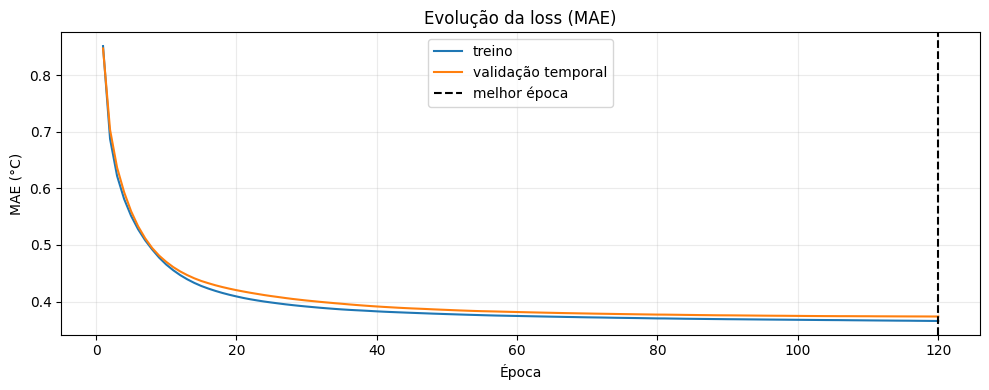

In [13]:
# Reajusta o modelo no treino completo e prevê o teste final.
def avaliar_previsoes(y, previsto, conjunto='teste'):
    residuo = (y - previsto).rename('residuo')
    mse = mean_squared_error(y, previsto)
    denominador = np.abs(y.to_numpy()) + np.abs(previsto.to_numpy())
    smape = np.mean(np.divide(
        2 * np.abs(y.to_numpy() - previsto.to_numpy()), denominador,
        out=np.zeros_like(denominador, dtype=float), where=denominador != 0
    )) * 100
    mape = (
        np.mean(np.abs((y.to_numpy() - previsto.to_numpy()) / y.to_numpy())) * 100
        if np.all(y.to_numpy() > 0) else np.nan
    )
    metricas = pd.DataFrame([{
        'conjunto': conjunto, 'n': len(y), 'MAE': mean_absolute_error(y, previsto),
        'MSE': mse, 'RMSE': mse ** 0.5, 'MAPE_percent': mape,
        'sMAPE_percent': smape, 'R2': r2_score(y, previsto),
        'vies_medio': residuo.mean(),
    }])
    return metricas, residuo

parametros_finais = {
    chave: melhor_configuracao[chave]
    for chave in ['hidden_layer_sizes', 'activation', 'solver', 'alpha']
}
modelo_mlp = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalonador', criar_escalonador(SCALER)),
    ('mlp', MLPRegressor(
        **parametros_finais, batch_size=BATCH_SIZE,
        max_iter=max(1, int(melhor_configuracao['melhor_epoca'])),
        early_stopping=False, shuffle=True, random_state=SEED,
    )),
])
inicio_avaliacao = time.perf_counter()
modelo_mlp.fit(X_train, y_train)
previsao_treino = pd.Series(modelo_mlp.predict(X_train), index=y_train.index, name='previsao')
metricas_treino, residuos_treino = avaliar_previsoes(y_train, previsao_treino, 'treino')

previsao_mlp = pd.Series(modelo_mlp.predict(X_test), index=y_test.index, name='previsao')
metricas_mlp, residuos_mlp = avaliar_previsoes(y_test, previsao_mlp, 'teste_final')
tempo_avaliacao = time.perf_counter() - inicio_avaliacao
metricas_comparacao = pd.concat([metricas_treino, metricas_mlp], ignore_index=True)
display(metricas_comparacao.round(4))
print('MAPE fica NaN porque a temperatura contém valores zero/negativos; use sMAPE.')
wf = pd.DataFrame({
    'modelo': 'MLP Regressor', 'origem': X_test.index,
    'ultima_hora_observada': X_test.index - pd.Timedelta(hours=1),
    'fim_intervalo_previsto': X_test.index + pd.Timedelta(hours=1),
    'data': X_test.index, 'passo': HORIZON,
    'real': y_test.to_numpy(), 'previsto': previsao_mlp.to_numpy(),
    'residuo': residuos_mlp.to_numpy(),
    'persistencia': X_test['target_lag_1'].to_numpy(),
    'sazonal_24h': X_test['target_lag_24'].to_numpy(),
})
previsoes_mlp = wf.set_index('data')[['real', 'previsto', 'residuo']]
display(wf.head())

resumo_early_stopping = {
    'configuracao': melhor_nome,
    'epocas_executadas': len(historico_mlp),
    'melhor_epoca': int(melhor_configuracao['melhor_epoca']),
    'melhor_MAE_validacao': tabela_busca.loc[0, 'MAE_validacao'],
    'patience': PATIENCE,
    'tempo_busca_min': tempo_busca / 60,
    'tempo_avaliacao_min': tempo_avaliacao / 60,
}
display(pd.DataFrame([resumo_early_stopping]))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico_mlp['epoca'], historico_mlp['MAE_treino'], label='treino')
ax.plot(historico_mlp['epoca'], historico_mlp['MAE_validacao'], label='validação temporal')
ax.axvline(resumo_early_stopping['melhor_epoca'], color='black', linestyle='--', label='melhor época')
ax.set(title='Evolução da loss (MAE)', xlabel='Época', ylabel='MAE (°C)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()



## Síntese técnica

- **Funcionamento:** aprende relações não lineares entre histórico, clima passado e ciclos de calendário.
- **Saída:** um neurônio linear produz a previsão contínua de temperatura.
- **Vantagens:** flexibilidade, inferência rápida e interação entre diferentes features.
- **Limitações:** sensibilidade à escala e à inicialização, extrapolação fraca e menor interpretabilidade.


In [14]:
# Resume as propriedades e os resultados do modelo selecionado.
print('Arquitetura selecionada:', melhor_configuracao['hidden_layer_sizes'])
print('Saída: linear, adequada à previsão contínua de temperatura.')
print('O sklearn otimiza erro quadrático; arquitetura e época são selecionadas por MAE temporal.')
print(f'Early stopping: patience={PATIENCE}; refit final usa a melhor época no treino completo.')
print('Teste: modelo congelado, com features causais atualizadas a cada origem, igual ao protocolo do RF.')
print('A MLP modela relações não lineares entre lags, exógenas e ciclos de calendário.')
print('Limitações: sensibilidade à escala, extrapolação fraca e dependência dos lags observados.')
display(metricas_comparacao.round(4))

Arquitetura selecionada: (32,)
Saída: linear, adequada à previsão contínua de temperatura.
O sklearn otimiza erro quadrático; arquitetura e época são selecionadas por MAE temporal.
Early stopping: patience=20; refit final usa a melhor época no treino completo.
Teste: modelo congelado, com features causais atualizadas a cada origem, igual ao protocolo do RF.
A MLP modela relações não lineares entre lags, exógenas e ciclos de calendário.
Limitações: sensibilidade à escala, extrapolação fraca e dependência dos lags observados.


,conjunto,n,MAE,MSE,RMSE,MAPE_percent,sMAPE_percent,R2,vies_medio
0,treino,55752,0.3714,0.2877,0.5364,NaN,9.6941,0.9959,0.0287
1,teste_final,13785,0.3821,0.2946,0.5427,NaN,8.0124,0.9955,0.0496


# 5. Avaliação


## Comparação com baselines

O resultado do MLP é comparado com referências simples:

- **persistência:** repete a última temperatura observada;
- **sazonal ingênuo:** repete a temperatura observada 24 horas antes.

Superar esses baselines confirma que a rede acrescenta informação além da continuidade e do ciclo diário.


In [15]:
# Compara o MLP com os baselines no teste final.
def resumir_metricas(nome, real, previsto):
    erro = np.asarray(real) - np.asarray(previsto)
    return {
        'modelo': nome, 'n': len(erro),
        'MAE': float(np.abs(erro).mean()),
        'RMSE': float(np.sqrt(np.mean(erro ** 2))),
        'R2': float(r2_score(real, previsto)),
        'vies_real_menos_previsto': float(erro.mean()),
        'P90_erro_absoluto': float(np.quantile(np.abs(erro), 0.9)),
        'MaxAE': float(np.abs(erro).max()),
    }

metricas = pd.DataFrame([
    resumir_metricas('MLP Regressor', wf['real'], wf['previsto']),
    resumir_metricas('Persistência (1h)', wf['real'], wf['persistencia']),
    resumir_metricas('Sazonal ingênuo (24h)', wf['real'], wf['sazonal_24h']),
])
mae_persistencia = metricas.loc[1, 'MAE']
metricas['ganho_MAE_vs_persistencia_pct'] = 100 * (1 - metricas['MAE'] / mae_persistencia)
display(metricas.round(4))
print(f'Busca: {tempo_busca / 60:.2f} min | treino e avaliação: {tempo_avaliacao / 60:.2f} min')
mensal = wf.set_index('data').resample('MS').apply({
    'residuo': lambda s: s.abs().mean(), 'real': 'count'
})
mensal.columns = ['MAE_MLP', 'n']
mensal['MAE_persistencia'] = (
    wf.set_index('data')['real'] - wf.set_index('data')['persistencia']
).abs().resample('MS').mean()


,modelo,n,MAE,RMSE,R2,vies_real_menos_previsto,P90_erro_absoluto,MaxAE,ganho_MAE_vs_persistencia_pct
0,MLP Regressor,13785,0.3821,0.5427,0.9955,0.0496,0.8243,6.6497,44.3481
1,Persistência (1h),13785,0.6865,0.9515,0.9863,-0.0010,1.5220,8.2100,0.0000
2,Sazonal ingênuo (24h),13785,2.5802,3.3774,0.8276,-0.0145,5.5617,15.0550,-275.8324


Busca: 5.19 min | treino e avaliação: 0.57 min


## Diagnóstico dos resíduos

- **Real vs. previsto:** mostra aderência e erros extremos.
- **Resíduo vs. previsto:** ajuda a identificar viés e variância não constante.
- **ACF:** revela dependências remanescentes entre os erros.
- **Ljung–Box:** testa estatisticamente a presença de autocorrelação.

> Um p-valor baixo indica que ainda existe estrutura temporal não capturada pelo modelo.


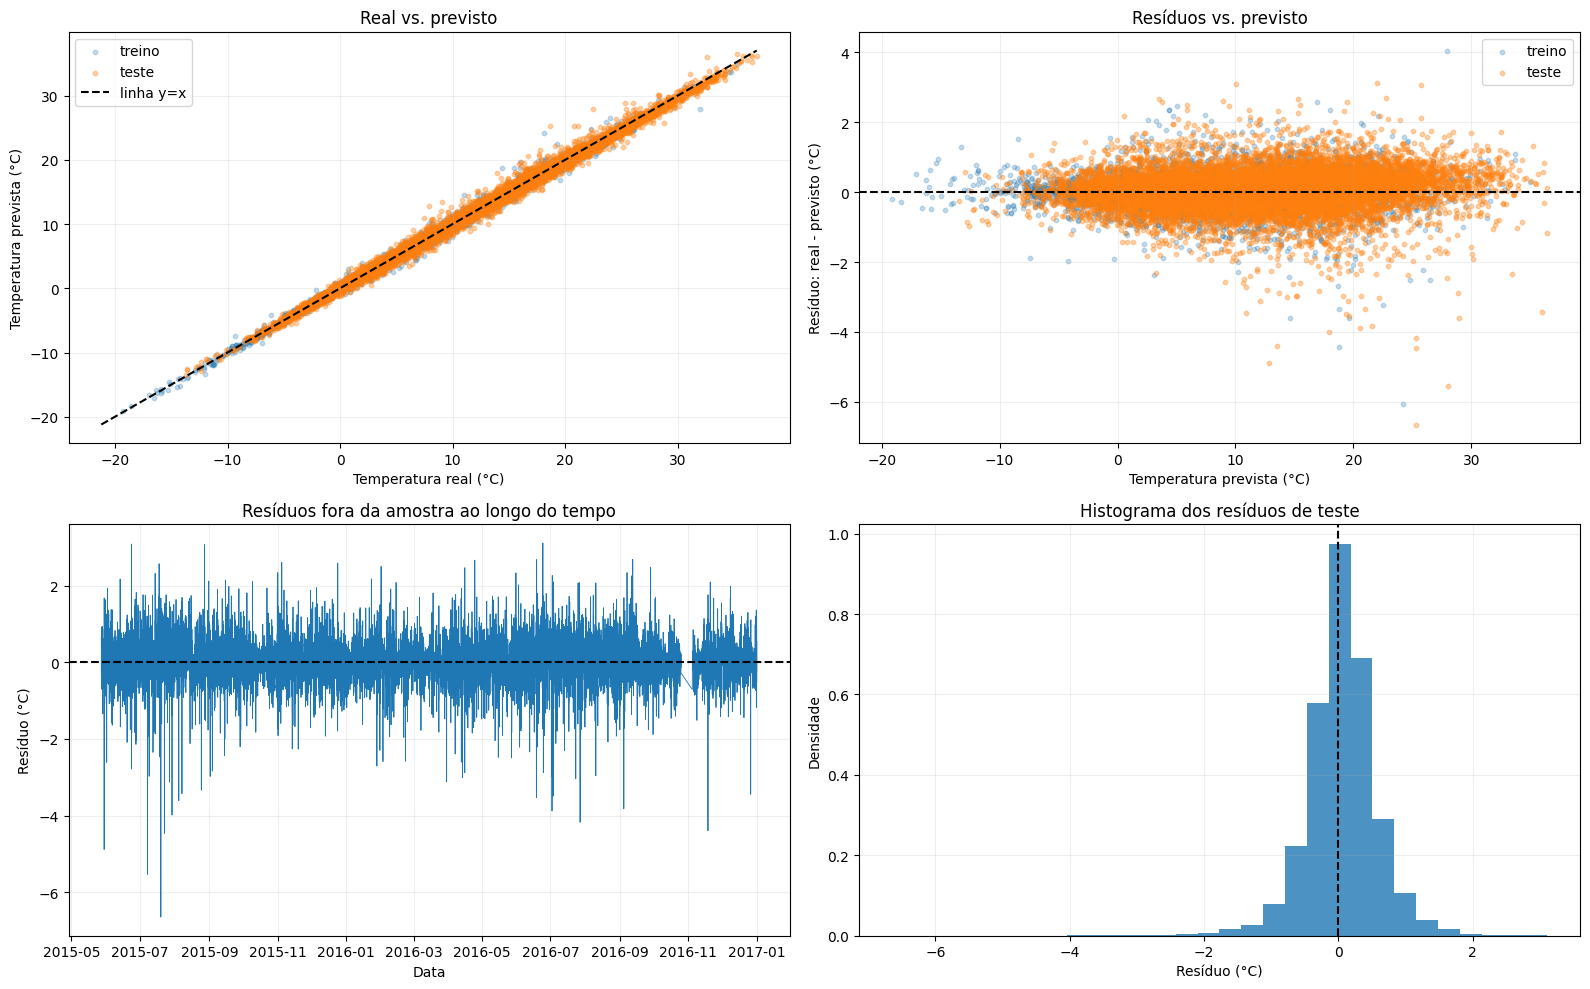

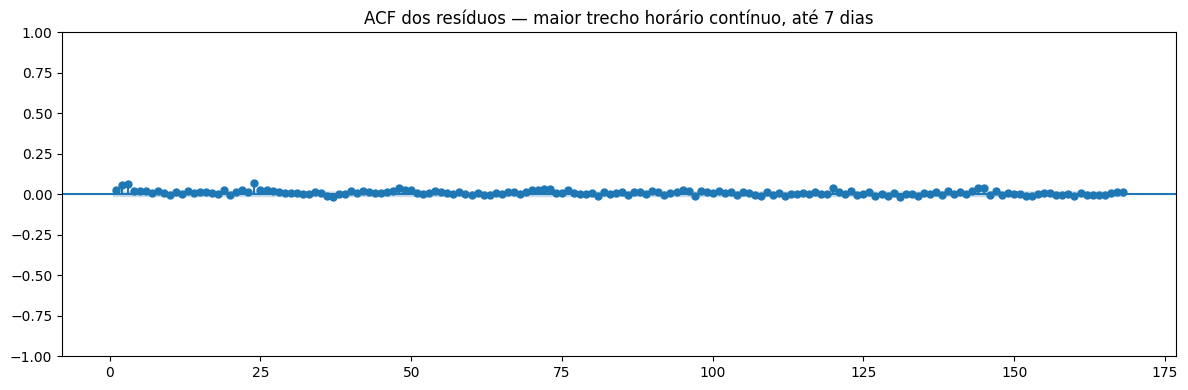

,lb_stat,lb_pvalue
lag_horas,,
1,9.588438,1.958064e-03
6,115.877215,1.195301e-22
12,127.873369,1.648092e-21
24,225.011226,1.397732e-34
48,306.323623,2.504525e-39
168,570.876299,2.486179e-45


Há evidência de autocorrelação residual (p < 0,05); ainda resta estrutura temporal não capturada.


In [16]:
# Diagnostica os resíduos fora da amostra.
residuos_mlp = wf.set_index('data')['residuo'].sort_index()
residuos_continuos = maior_trecho_continuo(residuos_mlp)
amostra_treino = previsao_treino.sample(n=min(5000, len(previsao_treino)), random_state=SEED).index
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

axes[0].scatter(y_train.loc[amostra_treino], previsao_treino.loc[amostra_treino], alpha=0.25, s=10, label='treino')
axes[0].scatter(y_test, previsao_mlp, alpha=0.35, s=10, label='teste')
mn = min(y_train.min(), y_test.min(), previsao_treino.min(), previsao_mlp.min())
mx = max(y_train.max(), y_test.max(), previsao_treino.max(), previsao_mlp.max())
axes[0].plot([mn, mx], [mn, mx], '--', color='black', label='linha y=x')
axes[0].set(title='Real vs. previsto', xlabel='Temperatura real (°C)', ylabel='Temperatura prevista (°C)')
axes[0].legend()

axes[1].scatter(previsao_treino.loc[amostra_treino], residuos_treino.loc[amostra_treino], alpha=0.25, s=10, label='treino')
axes[1].scatter(previsao_mlp, residuos_mlp, alpha=0.35, s=10, label='teste')
axes[1].axhline(0, linestyle='--', color='black')
axes[1].set(title='Resíduos vs. previsto', xlabel='Temperatura prevista (°C)', ylabel='Resíduo: real - previsto (°C)')
axes[1].legend()

axes[2].plot(residuos_mlp.index, residuos_mlp, linewidth=0.6)
axes[2].axhline(0, linestyle='--', color='black')
axes[2].set(title='Resíduos fora da amostra ao longo do tempo', xlabel='Data', ylabel='Resíduo (°C)')

axes[3].hist(residuos_mlp, bins=30, density=True, alpha=0.8)
axes[3].axvline(0, linestyle='--', color='black')
axes[3].set(title='Histograma dos resíduos de teste', xlabel='Resíduo (°C)', ylabel='Densidade')
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(residuos_continuos, lags=168, zero=False, ax=ax)
ax.set_title('ACF dos resíduos — maior trecho horário contínuo, até 7 dias')
plt.tight_layout(); plt.show()

ljung_box_mlp = acorr_ljungbox(
    residuos_continuos, lags=[1, 6, 12, 24, 48, 168], return_df=True
)
ljung_box_mlp.index.name = 'lag_horas'
display(ljung_box_mlp)
if (ljung_box_mlp['lb_pvalue'] < 0.05).any():
    print('Há evidência de autocorrelação residual (p < 0,05); ainda resta estrutura temporal não capturada.')
else:
    print('Não há evidência de autocorrelação residual nos lags avaliados (p >= 0,05).')


## Importância das features

A importância por permutação embaralha uma feature por vez e mede o aumento do MAE:

- aumento maior significa maior contribuição preditiva;
- valores próximos de zero indicam pouca contribuição isolada;
- features correlacionadas podem dividir importância entre si.

O método melhora a interpretação sem alterar o modelo treinado.


,feature,importancia,desvio_importancia,metodo,coeficiente,p_valor
0,target_lag_1,10.1874,0.0913,permutacao,NaN,NaN
1,target_lag_2,2.8245,0.0339,permutacao,NaN,NaN
2,target_lag_3,0.3064,0.0084,permutacao,NaN,NaN
3,hora_cos,0.2572,0.0071,permutacao,NaN,NaN
4,target_roll_mean_6,0.1769,0.0051,permutacao,NaN,NaN
5,target_roll_mean_24,0.1194,0.0038,permutacao,NaN,NaN
6,dia_ano_cos,0.0658,0.0033,permutacao,NaN,NaN
7,target_lag_6,0.0416,0.0026,permutacao,NaN,NaN
8,hora_sin,0.0412,0.0031,permutacao,NaN,NaN
9,target_lag_12,0.0281,0.0014,permutacao,NaN,NaN


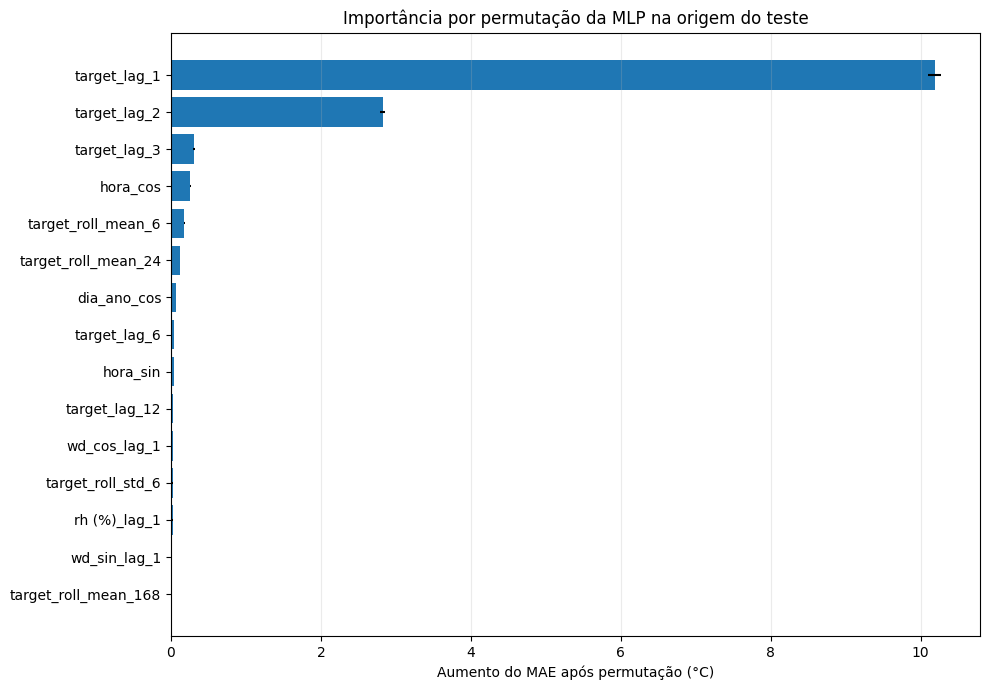

Principais features: target_lag_1, target_lag_2, target_lag_3, hora_cos, target_roll_mean_6
A importância mede o aumento do MAE ao embaralhar cada feature; valores maiores indicam maior contribuição preditiva.


,feature,importancia,desvio_importancia,metodo,coeficiente,p_valor
10,wd_cos_lag_1,0.0238,0.0021,permutacao,NaN,NaN
12,rh (%)_lag_1,0.0215,0.0021,permutacao,NaN,NaN
13,wd_sin_lag_1,0.0163,0.0021,permutacao,NaN,NaN
15,wv (m/s)_lag_1,0.0087,0.0015,permutacao,NaN,NaN
19,p (mbar)_lag_1,0.0062,0.0019,permutacao,NaN,NaN
20,p (mbar)_lag_24,0.0052,0.0011,permutacao,NaN,NaN
21,rh (%)_lag_24,0.0051,0.0007,permutacao,NaN,NaN
23,wd_cos_lag_24,0.0018,0.0008,permutacao,NaN,NaN
26,wd_sin_lag_24,0.0011,0.0007,permutacao,NaN,NaN
28,wv (m/s)_lag_24,0.0001,0.0006,permutacao,NaN,NaN


Exógenas são medições passadas; nenhuma observação meteorológica futura foi usada.


In [17]:
# Estima a importância das features por permutação.
importancias_mlp = calcular_importancia_features(
    modelo_mlp, X_test, y_test, metodo='permutacao',
    n_repeticoes=10, seed=SEED, n_jobs=-1, max_amostras=3000,
)
display(importancias_mlp.head(15).round(4))
top = importancias_mlp.head(15).sort_values('importancia')
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top['feature'], top['importancia'], xerr=top['desvio_importancia'])
ax.set_title('Importância por permutação da MLP na origem do teste')
ax.set_xlabel('Aumento do MAE após permutação (°C)')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout(); plt.show()
print('Principais features:', ', '.join(importancias_mlp.head(5)['feature']))
print('A importância mede o aumento do MAE ao embaralhar cada feature; valores maiores indicam maior contribuição preditiva.')
prefixos_exogenas = tuple(EXOG_COLUMNS)
importancias_exogenas = importancias_mlp[
    importancias_mlp['feature'].str.startswith(prefixos_exogenas)
].head(10)
display(importancias_exogenas.round(4))
print('Exógenas são medições passadas; nenhuma observação meteorológica futura foi usada.')


In [10]:
from IPython.display import display
from walk_forward import validar_previsoes
checagem = validar_previsoes(BASE_NAME, wf["data"], PROJECT_ROOT)
assert checagem["ok"], checagem
print(f"MAE RECONSTRUIDO: {np.mean(np.abs(wf["real"]-wf["previsto"])):.8f} | n={len(wf)}")
resultado = [{"data": str(d), "real": float(r), "previsto": float(v)} for d, r, v in wf[["data","real","previsto"]].itertuples(index=False, name=None)]
import base64, zlib, json
_carga_compacta = base64.b64encode(zlib.compress(json.dumps(resultado, ensure_ascii=False, separators=(',', ':'), allow_nan=False).encode('utf-8'), 9)).decode('ascii')
display({'application/vnd.series-temporais.previsoes+json': {'formato': 'json-zlib-base64', 'dados': _carga_compacta}}, raw=True)

MAE RECONSTRUIDO: 0.38207081 | n=13785
